<a href="https://colab.research.google.com/github/Sivaganesh8960/Sentiment-Analysis-for-Political-Campaigns/blob/main/final_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# File handling & data processing
import os
import zipfile
import pandas as pd

# Text preprocessing
import re
import string

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Display settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 200)

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# STEP 1: Dataset Extraction and Inspection

import os
import zipfile
import pandas as pd
import re

# Define ZIP path and extraction folder
zip_path = '/content/tweet.zip'
extract_path = '/content/tweet_data'

# STEP 1.1: Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# STEP 1.2: List extracted files
print("📂 Extracted Files:")
extracted_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        filepath = os.path.join(root, file)
        extracted_files.append(filepath)
        print(filepath)

# STEP 1.3: Load the CSV file (assume only one for now)
csv_file = extracted_files[0]  # should be /content/tweet_data/tweets.csv
df = pd.read_csv(csv_file)

# STEP 1.4: Inspect the dataset
print("\n📄 Columns in the dataset:")
print(df.columns)
print("\n🔍 Dataset Shape:", df.shape)
print("\n📊 Sample Rows:")
print(df.sample(5))

# STEP 1.5: Add 'party' column using improved keyword matching
bjp_keywords = ['modi', 'bjp', 'amit shah', 'yogi', 'narendra modi', 'namo', 'jay shah']
congress_keywords = ['rahul', 'congress', 'sonia', 'inc', 'priyanka', 'gandhi', 'shashi tharoor']

def classify_party(text):
    text = str(text).lower()
    for keyword in bjp_keywords:
        if re.search(r'\b' + re.escape(keyword) + r'\b', text):
            return 'BJP'
    for keyword in congress_keywords:
        if re.search(r'\b' + re.escape(keyword) + r'\b', text):
            return 'Congress'
    return 'Unknown'

df['party'] = df['Tweet'].apply(classify_party)

# STEP 1.6: Distribution and filtering
print("\n✅ Tweet Distribution by Party:")
print(df['party'].value_counts())

# Keep only BJP and Congress tweets
df = df[df['party'].isin(['BJP', 'Congress'])].reset_index(drop=True)
print("\n📊 Final Dataset Shape after filtering:", df.shape)


📂 Extracted Files:
/content/tweet_data/tweets.csv
/content/tweet_data/processed_tweets_with_processed_text.csv

📄 Columns in the dataset:
Index(['Unnamed: 0', 'Date', 'User', 'Tweet', 'Likes', 'Retweets'], dtype='object')

🔍 Dataset Shape: (50001, 6)

📊 Sample Rows:
      Unnamed: 0                       Date            User  \
33553      33552  2022-12-02 10:51:11+00:00        fekubawa   
9427        9427  2023-03-07 04:05:38+00:00       IRASP_UWA   
199          199  2023-03-29 09:36:41+00:00    WhybotherMeh   
12447      12447  2023-02-25 10:38:25+00:00   albert_colaco   
39489      39488  2022-11-11 11:20:19+00:00  adwitiya_singh   

                                                                                                                                                                                                         Tweet  \
33553                                                                                                             @desimojito Yeah and since 201

In [ ]:
!pip install -q spacy emoji
!python -m spacy download en_core_web_sm
import nltk
nltk.download('stopwords')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# 📦 Imports
import re
import emoji
import spacy
import nltk
import pandas as pd
from nltk.corpus import stopwords
from tqdm import tqdm

# 📥 NLTK Downloads
nltk.download('stopwords')
tqdm.pandas(desc="Processing")

# 🔧 Load spaCy model and stopwords
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])  # speed up
stop_words = set(stopwords.words("english"))

# ✨ Clean raw tweet text
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)   # remove URLs
    text = re.sub(r"@\w+|#\w+", '', text)                 # remove mentions/hashtags
    text = emoji.replace_emoji(text, replace='')          # remove emojis
    text = re.sub(r"[^\w\s]", '', text)                   # remove punctuation
    text = re.sub(r"\d+", '', text)                       # remove numbers
    text = re.sub(r"\s+", " ", text).strip()              # remove extra spaces
    return text

# 🧠 Tokenize, Lemmatize, Remove Stopwords
def tokenize_lemmatize(text):
    doc = nlp(text)
    tokens = [token.lemma_.lower() for token in doc if token.is_alpha and token.text.lower() not in stop_words]
    return " ".join(tokens)

# 🧹 Apply cleaning and processing
df['cleaned_text'] = df['Tweet'].progress_apply(clean_text)
df['processed_text'] = df['cleaned_text'].progress_apply(tokenize_lemmatize)

# 🖼️ View sample processed tweets
print("\n📌 Sample Processed Text:")
print(df[['Tweet', 'processed_text']].sample(5))

# 💾 Save cleaned dataset
processed_path = "/content/tweet_data/processed_tweets_with_processed_text.csv"
df.to_csv(processed_path, index=False)
print(f"\n✅ Processed text saved to: {processed_path}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Processing: 100%|██████████| 10194/10194 [01:18<00:00, 129.69it/s]



📌 Sample Processed Text:
                                                                                                                                                                                                        Tweet  \
7891  Predictions of @ArvindKejriwal so far\n\nGujarat:\n-Seats of Congress &lt;=5\n-Vote share of BJP &lt;38%\n-Seats of AAP in Surat &gt;=8\n-AAP forming government \n\nDelhi MCD:\n-AAP forming govern...   
689   @republic If this man is saying Modi disqualified him then why did he go to SC to seek cancellation of  lower court order? All politics to fool people. If SC dismisses these will blame SC too. In ...   
6269  Dec 1945:\n"Jinnah had toldhim that he (Gandhi)had ruined politics in India bydragging up lot of unwholesome elements in Indian life &amp; givingthem political prominence,that it was a crime to mi...   
4157                                                                        @vikrantgupta73 Rohit and Rahul shouldn't be in the team at al

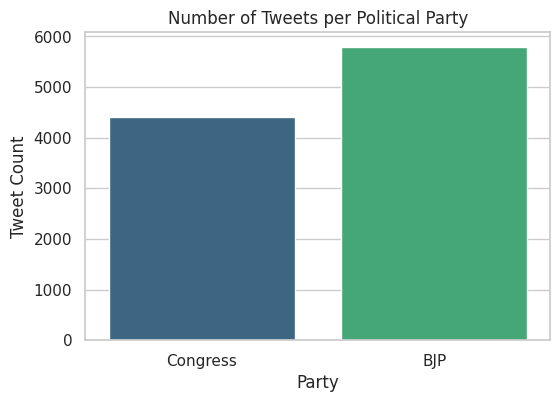

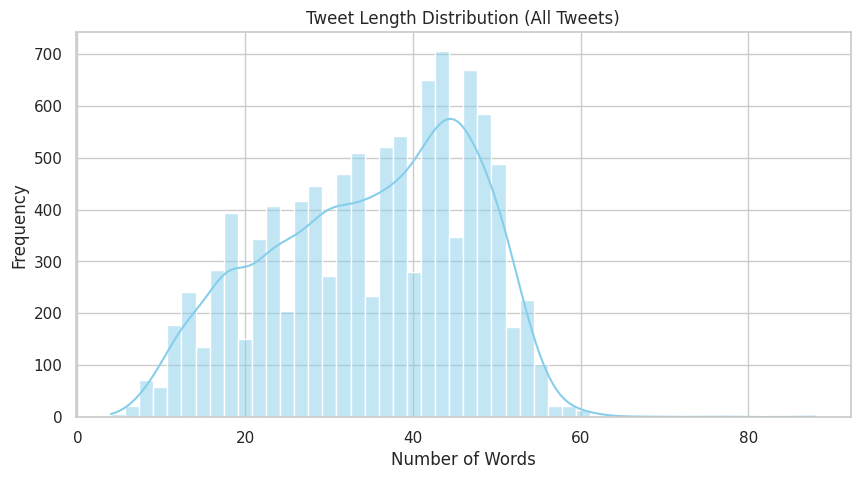

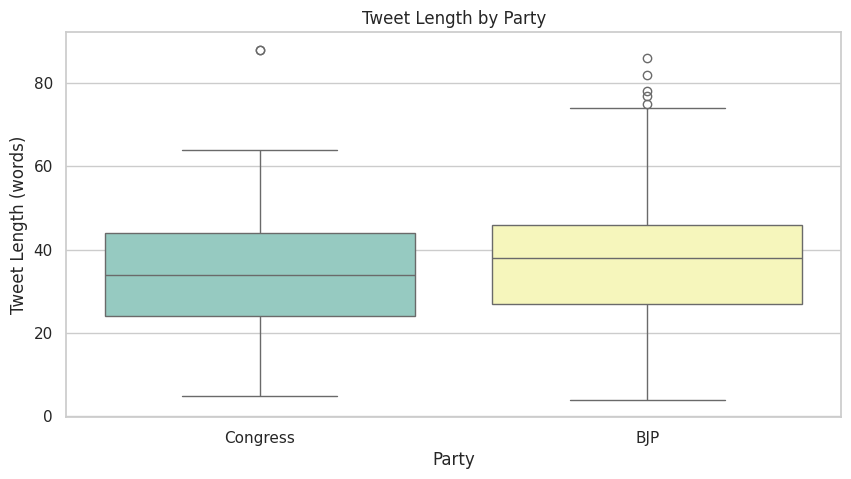

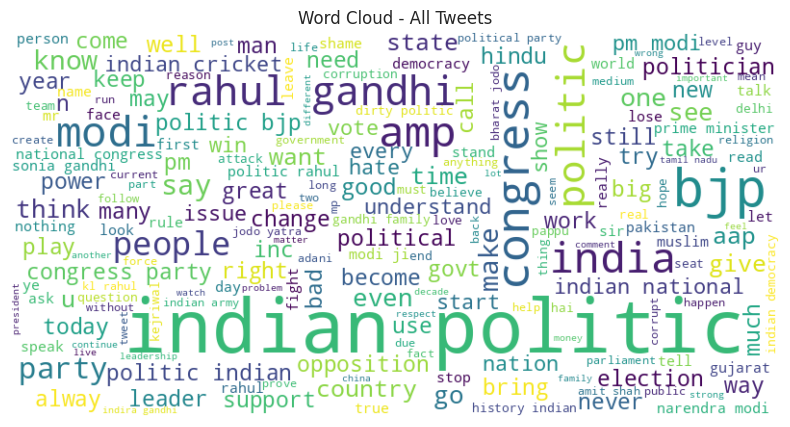

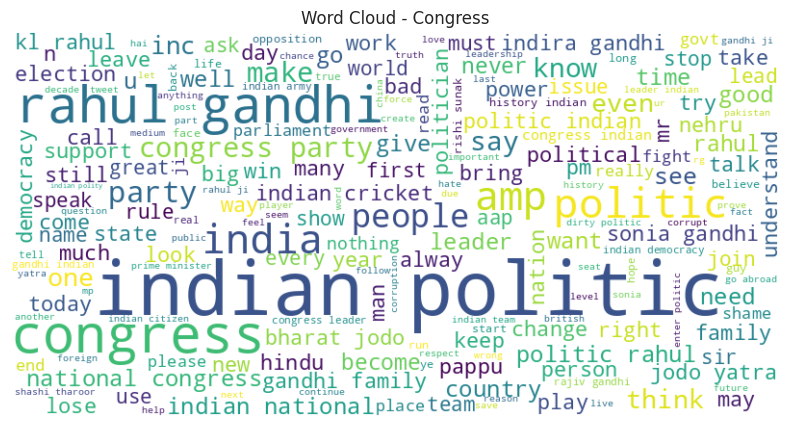

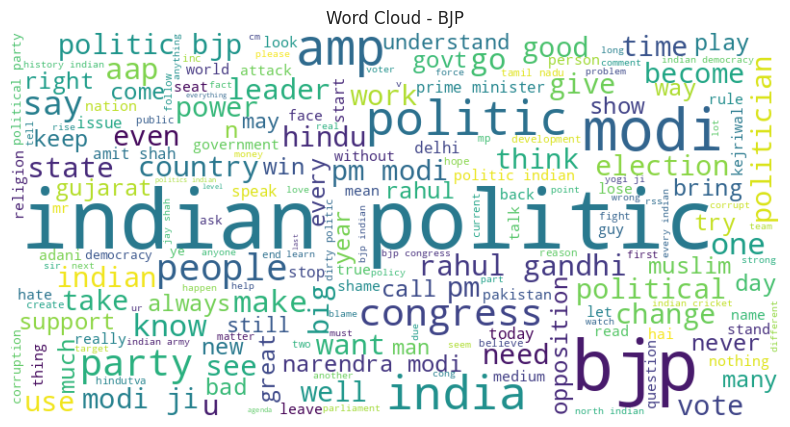

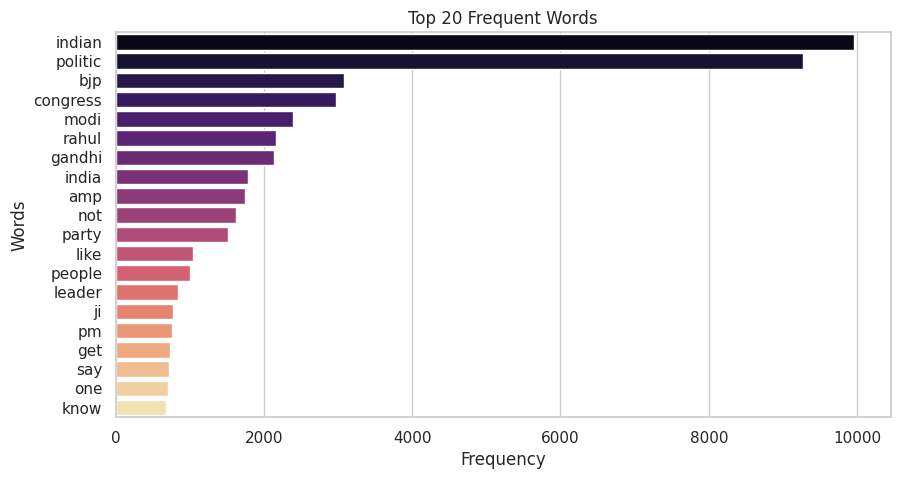

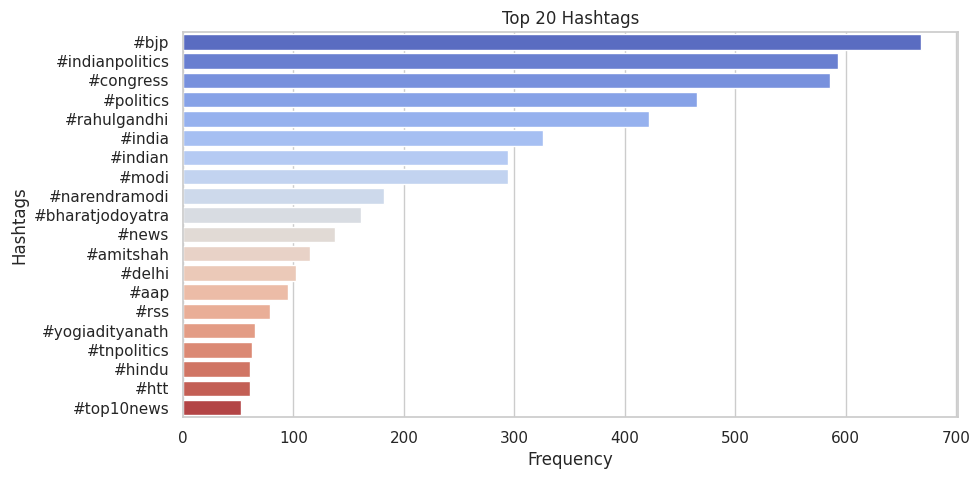

In [ ]:
# ✅ Setup
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import pandas as pd

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 1️⃣ Tweet Count per Party
if 'party' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='party', palette='viridis')
    plt.title("Number of Tweets per Political Party")
    plt.xlabel("Party")
    plt.ylabel("Tweet Count")
    plt.show()

# 2️⃣ Tweet Length Distribution (Overall)
df['tweet_length'] = df['Tweet'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.histplot(df['tweet_length'], bins=50, kde=True, color='skyblue')
plt.title("Tweet Length Distribution (All Tweets)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# 2️⃣.1 Tweet Length by Party (NEW)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='party', y='tweet_length', palette='Set3')
plt.title("Tweet Length by Party")
plt.xlabel("Party")
plt.ylabel("Tweet Length (words)")
plt.show()

# 3️⃣ Word Cloud – All Tweets Combined
all_words = ' '.join(df['processed_text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - All Tweets")
plt.show()

# 3️⃣.1 Word Cloud by Party (NEW)
for party in df['party'].unique():
    party_words = ' '.join(df[df['party'] == party]['processed_text'].dropna())
    wc = WordCloud(width=800, height=400, background_color='white').generate(party_words)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {party}")
    plt.show()

# 4️⃣ Most Frequent Words
word_list = all_words.split()
word_freq = Counter(word_list)
common_words = word_freq.most_common(20)

words, freqs = zip(*common_words)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(freqs), y=list(words), palette="magma")
plt.title("Top 20 Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

# 5️⃣ Most Used Hashtags
def extract_hashtags(text):
    return [tag.lower() for tag in re.findall(r"#\w+", str(text))]

df['hashtags'] = df['Tweet'].apply(extract_hashtags)
all_hashtags = sum(df['hashtags'], [])
hashtag_freq = Counter(all_hashtags)
common_hashtags = hashtag_freq.most_common(20)

if common_hashtags:
    tags, counts = zip(*common_hashtags)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(tags), palette='coolwarm')
    plt.title("Top 20 Hashtags")
    plt.xlabel("Frequency")
    plt.ylabel("Hashtags")
    plt.show()
else:
    print("⚠ No hashtags found in the dataset.")

# 6️⃣ Sentiment Distribution (if exists)
if 'sentiment' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette='Set2')
    plt.title("Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()


✅ Columns 'vader_score' and 'sentiment' added and saved to: /content/tweet_data/processed_tweets_with_processed_text.csv


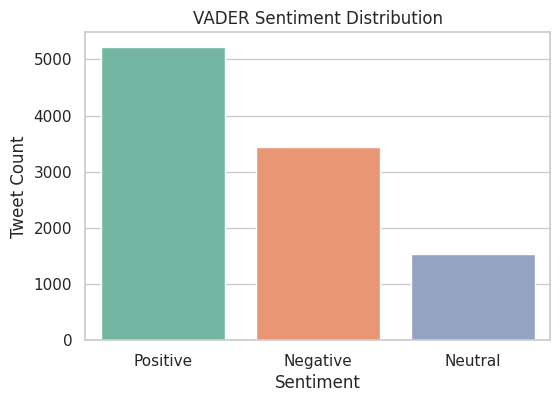

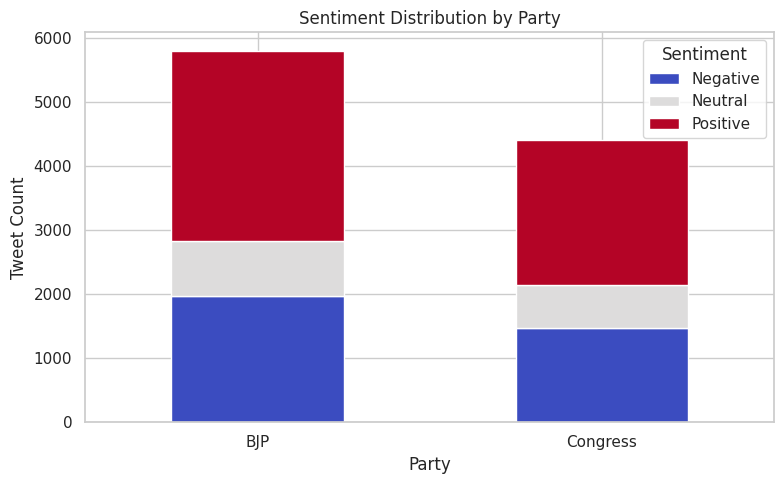

In [ ]:
# 📦 Install VADER if not already installed
!pip install vaderSentiment --quiet

# 🛠️ Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 📂 File path
file_path = "/content/tweet_data/processed_tweets_with_processed_text.csv"

# 📥 Load existing CSV
df = pd.read_csv(file_path)

# ✅ Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# 🧠 Function to map sentiment score to label
def get_sentiment(score, neutral_range=0.05):  # Adjust range for Neutral if needed
    if score >= neutral_range:
        return "Positive"
    elif score <= -neutral_range:
        return "Negative"
    else:
        return "Neutral"

# 🧪 Choose text column (prefer 'processed_text' if available)
text_col = 'processed_text' if 'processed_text' in df.columns else 'Tweet'

# 🔍 Apply VADER sentiment scoring
df['vader_score'] = df[text_col].astype(str).apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['sentiment'] = df['vader_score'].apply(lambda x: get_sentiment(x, neutral_range=0.05))

# 💾 Save changes back to CSV
df.to_csv(file_path, index=False)
print(f"✅ Columns 'vader_score' and 'sentiment' added and saved to: {file_path}")

# 📊 Visualize Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='Set2', order=df['sentiment'].value_counts().index)
plt.title("VADER Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.show()

# 📊 Sentiment Distribution by Political Party
if 'party' in df.columns:
    sentiment_party = df.groupby(['party', 'sentiment']).size().unstack().fillna(0)

    sentiment_party.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 5))
    plt.title("Sentiment Distribution by Party")
    plt.xlabel("Party")
    plt.ylabel("Tweet Count")
    plt.xticks(rotation=0)
    plt.legend(title="Sentiment")
    plt.tight_layout()
    plt.show()


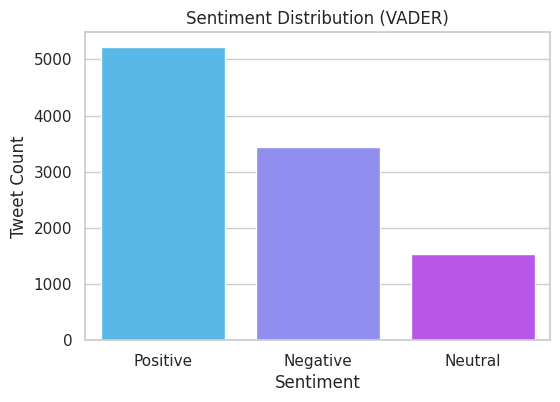

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='cool')
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.show()



🔧 Training: Logistic Regression
✅ Accuracy: 0.7425
📄 Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.74      0.74       687
     Neutral       0.51      0.63      0.56       308
    Positive       0.83      0.78      0.80      1044

    accuracy                           0.74      2039
   macro avg       0.70      0.72      0.70      2039
weighted avg       0.75      0.74      0.75      2039


🔧 Training: Naive Bayes
✅ Accuracy: 0.6945
📄 Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.65      0.67       687
     Neutral       0.76      0.23      0.35       308
    Positive       0.69      0.86      0.77      1044

    accuracy                           0.69      2039
   macro avg       0.71      0.58      0.60      2039
weighted avg       0.70      0.69      0.67      2039


🔧 Training: Linear SVM
✅ Accuracy: 0.7528
📄 Classification Report:
              precision 

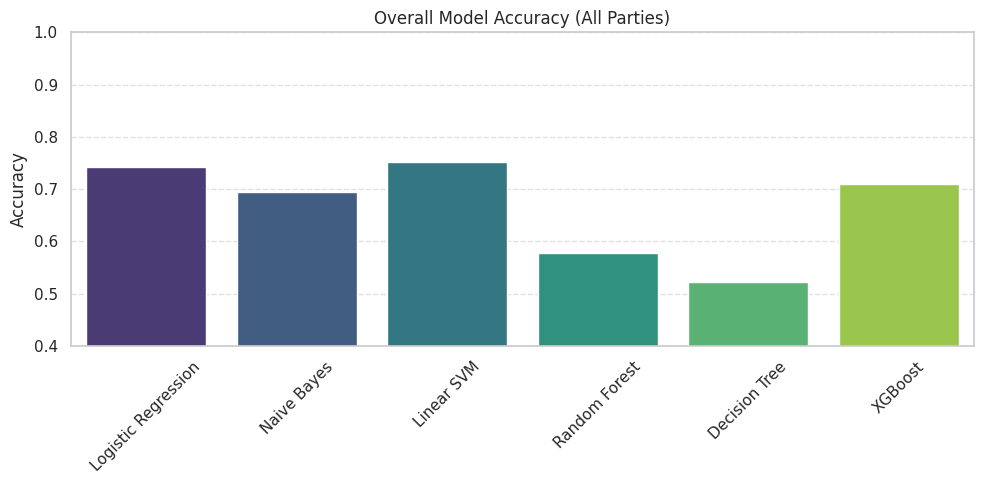

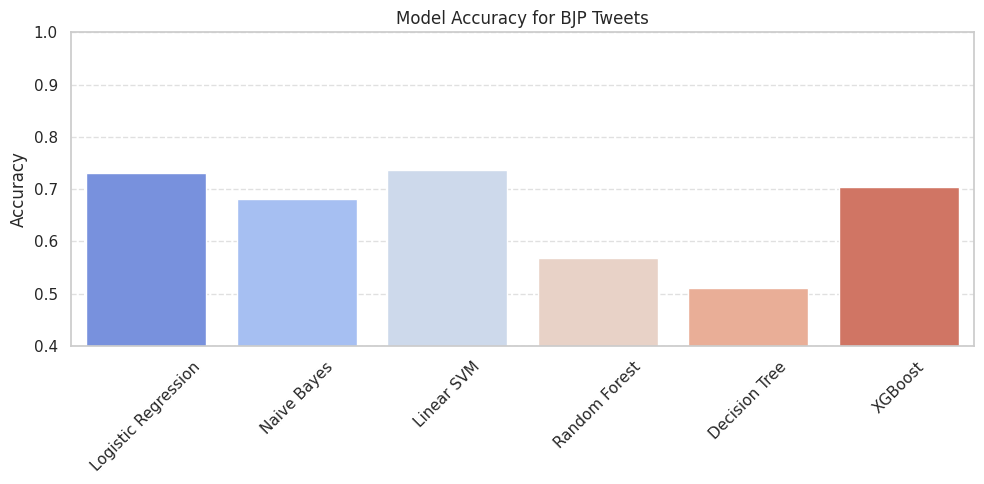

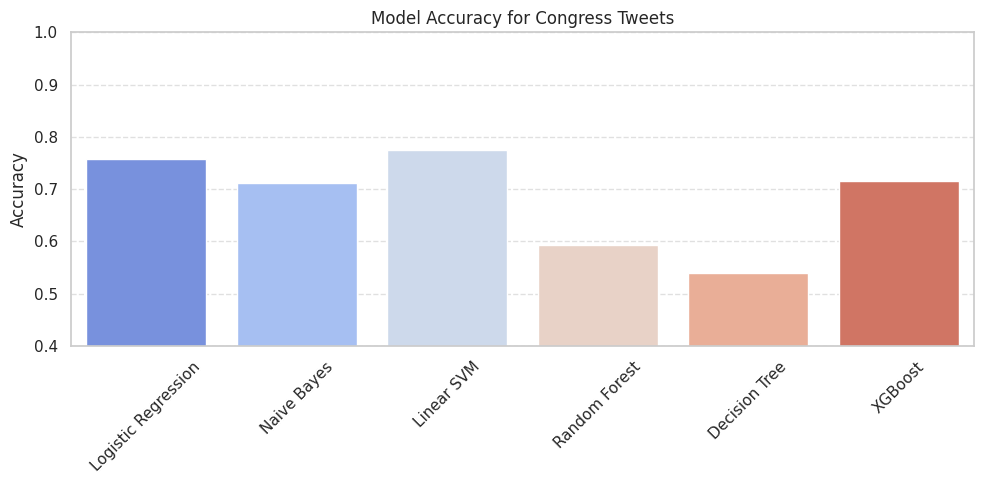

In [ ]:
# ✅ Install required packages (quiet mode)
!pip install scikit-learn xgboost seaborn --quiet

# ✅ Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# 📂 Load Data
df = pd.read_csv("/content/tweet_data/processed_tweets_with_processed_text.csv")

# ✅ Safety Check
required_cols = ['processed_text', 'sentiment', 'party']
if not all(col in df.columns for col in required_cols):
    raise ValueError(f"❌ Missing required columns: {required_cols}")

df.dropna(subset=required_cols, inplace=True)

# 🔠 Encode Labels
label_encoder = LabelEncoder()
df['encoded_sentiment'] = label_encoder.fit_transform(df['sentiment'])

# 🧠 TF-IDF Vectorization (optimized for performance + accuracy)
tfidf = TfidfVectorizer(
    max_features=15000,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)
X = tfidf.fit_transform(df['processed_text'])
y = df['encoded_sentiment']

# 🔀 Train/Test Split
X_train, X_test, y_train, y_test, party_train, party_test = train_test_split(
    X, y, df['party'], test_size=0.2, stratify=y, random_state=42
)

# 🤖 Model Definitions
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.5, class_weight='balanced'),
    "Naive Bayes": MultinomialNB(alpha=0.2),
    "Linear SVM": LinearSVC(C=1.2, class_weight='balanced', max_iter=1500),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=25, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=200, max_depth=5, learning_rate=0.1)
}

# 📊 Results Containers
overall_results = {}
party_results = {"BJP": {}, "Congress": {}}

# 🏋️ Train and Evaluate
for name, model in models.items():
    print(f"\n🔧 Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    overall_results[name] = acc
    print(f"✅ Accuracy: {acc:.4f}")
    print(f"📄 Classification Report:\n{classification_report(y_test, y_pred, target_names=label_encoder.classes_)}")

    # 📊 Per-party Accuracy
    for party in party_results.keys():
        party_mask = party_test.str.lower() == party.lower()
        party_acc = accuracy_score(y_test[party_mask], y_pred[party_mask])
        party_results[party][name] = party_acc

# 📈 Plot: Overall Accuracy
plt.figure(figsize=(10, 5))
sns.barplot(x=list(overall_results.keys()), y=list(overall_results.values()), palette='viridis')
plt.ylabel('Accuracy')
plt.title('Overall Model Accuracy (All Parties)')
plt.ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 📈 Plot: Party-wise Accuracy
for party, results in party_results.items():
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
    plt.ylabel('Accuracy')
    plt.title(f'Model Accuracy for {party} Tweets')
    plt.ylim(0.4, 1.0)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


✅ Logistic Regression - Overall Accuracy: 0.7543
✅ Random Forest - Overall Accuracy: 0.5743
✅ Naive Bayes - Overall Accuracy: 0.6837
✅ Linear SVM - Overall Accuracy: 0.7518
✅ Decision Tree - Overall Accuracy: 0.4605
✅ XGBoost - Overall Accuracy: 0.7680


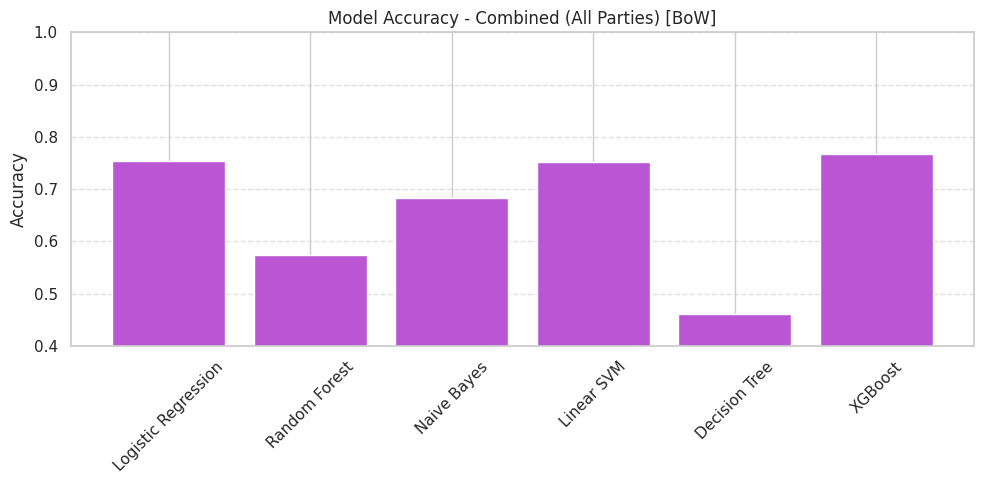

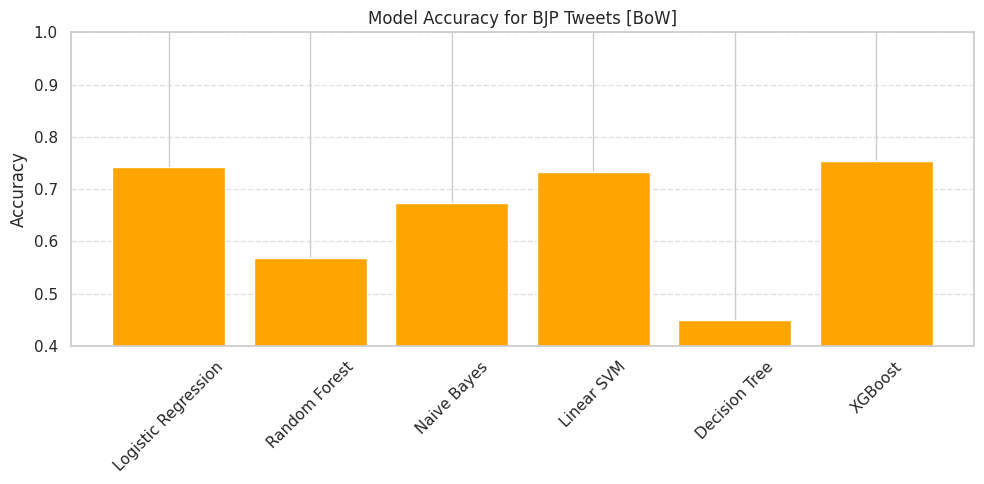

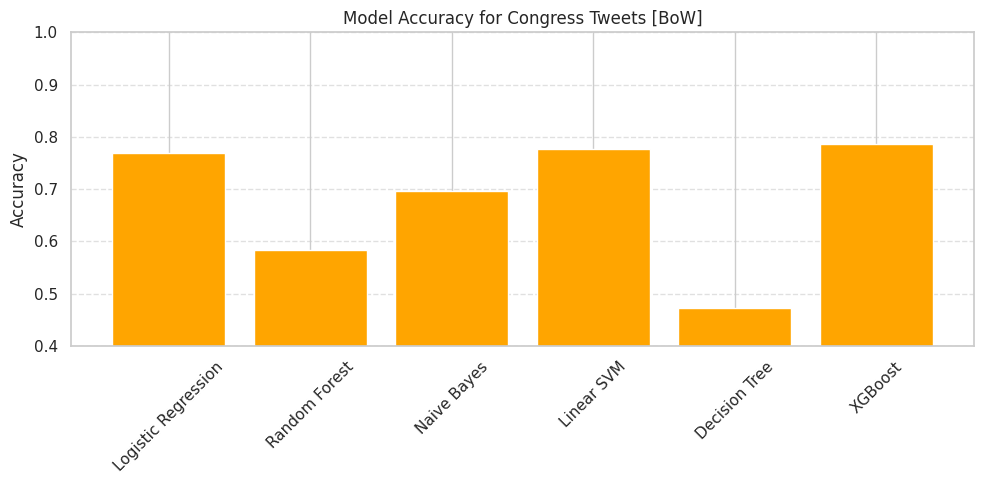

In [ ]:
# 📦 Imports
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 📥 Load dataset
df = pd.read_csv("/content/tweet_data/processed_tweets_with_processed_text.csv")

# 🧼 Drop rows with missing values
df.dropna(subset=['processed_text', 'sentiment', 'party'], inplace=True)

# 🧾 Bag of Words Vectorization
bow_vectorizer = CountVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words='english'
)
X = bow_vectorizer.fit_transform(df['processed_text'])

# 🎯 Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])

# 🔀 Train/test split
X_train, X_test, y_train, y_test, party_train, party_test = train_test_split(
    X, y, df['party'], test_size=0.2, stratify=y, random_state=42
)

# 🤖 Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "Naive Bayes": MultinomialNB(alpha=0.3),
    "Linear SVM": LinearSVC(C=1.0, class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', max_depth=6, n_estimators=150)
}

# 📊 Store results
overall_results = {}
party_results = {"BJP": {}, "Congress": {}}

# 🧠 Evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Overall accuracy
    overall_acc = accuracy_score(y_test, y_pred)
    overall_results[name] = overall_acc

    # Per-party accuracy
    for party in party_results:
        indices = party_test.str.lower() == party.lower()
        party_acc = accuracy_score(y_test[indices], y_pred[indices])
        party_results[party][name] = party_acc

    print(f"✅ {name} - Overall Accuracy: {overall_acc:.4f}")

# 📊 Plot overall accuracy
plt.figure(figsize=(10, 5))
plt.bar(overall_results.keys(), overall_results.values(), color='mediumorchid')
plt.ylabel('Accuracy')
plt.title('Model Accuracy - Combined (All Parties) [BoW]')
plt.ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 📊 Plot per-party accuracy
for party in party_results:
    plt.figure(figsize=(10, 5))
    plt.bar(party_results[party].keys(), party_results[party].values(), color='orange')
    plt.ylabel('Accuracy')
    plt.title(f'Model Accuracy for {party} Tweets [BoW]')
    plt.ylim(0.4, 1.0)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
